# Phase 4 — Supplier EDA

Lead time & variability, on-time delivery, a quality proxy, cost, and a formal hypothesis test on lead-time variability across suppliers.

**Prerequisite:** `make etl` has been run and `DATABASE_URL` points at the populated warehouse.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from src.eda import data_access, stats_tests

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")


In [2]:
shipments = data_access.load_shipment_detail()
returns = data_access.load_returns_detail()
shipments.shape, returns.shape

((180519, 18), (22102, 8))

## 1. Lead time & variability

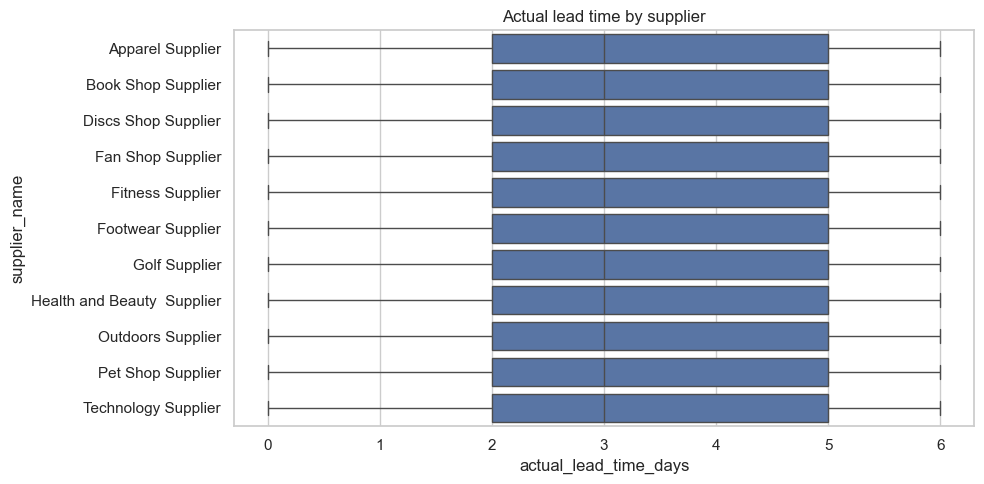

,supplier_name,standard_lead_time_days,avg_actual_lead_time_days,lead_time_stddev_days
0,Discs Shop Supplier,7,3.60,1.60
1,Apparel Supplier,9,3.50,1.60
2,Golf Supplier,4,3.50,1.60
3,Health and Beauty Supplier,6,3.50,1.60
4,Outdoors Supplier,20,3.50,1.60
5,Fan Shop Supplier,11,3.50,1.60
6,Fitness Supplier,10,3.50,1.60
7,Footwear Supplier,19,3.50,1.60
8,Book Shop Supplier,3,3.40,1.70
9,Pet Shop Supplier,10,3.40,1.70


In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
order = shipments.groupby('supplier_name')['actual_lead_time_days'].median().sort_values().index
sns.boxplot(data=shipments, x='actual_lead_time_days', y='supplier_name', order=order, ax=ax)
ax.set_title('Actual lead time by supplier')
plt.tight_layout()
plt.show()

data_access.run_sql_file('04_supplier/02_average_lead_time_by_supplier.sql')

## 2. On-time delivery

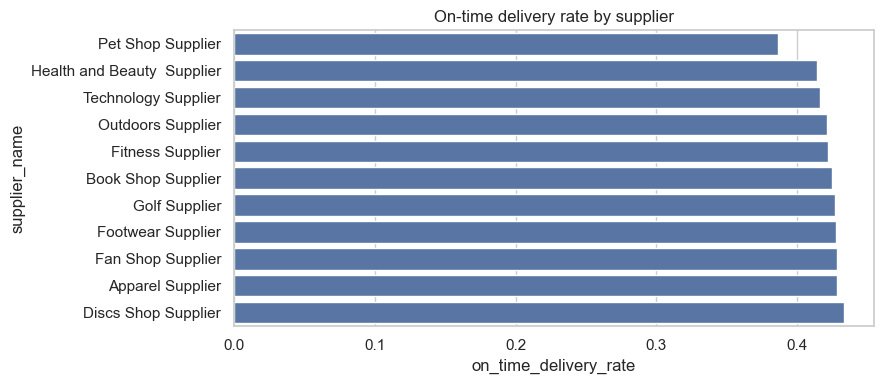

In [4]:
otd = data_access.run_sql_file('04_supplier/03_supplier_on_time_rate.sql')
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(
    data=otd.sort_values('on_time_delivery_rate'),
    x='on_time_delivery_rate', y='supplier_name', ax=ax,
)
ax.set_title('On-time delivery rate by supplier')
plt.tight_layout()
plt.show()

## 3. Quality (proxy)

Neither Olist nor DataCo records a defect/quality field, so this is an explicit **proxy**, not a real QA metric: the share of a supplier's shipped units whose sale was later returned with reason `'Defective item'` (itself a synthetic label, see `etl/synthesize/returns.py`). Framed as illustrative, not a claim about real product quality.

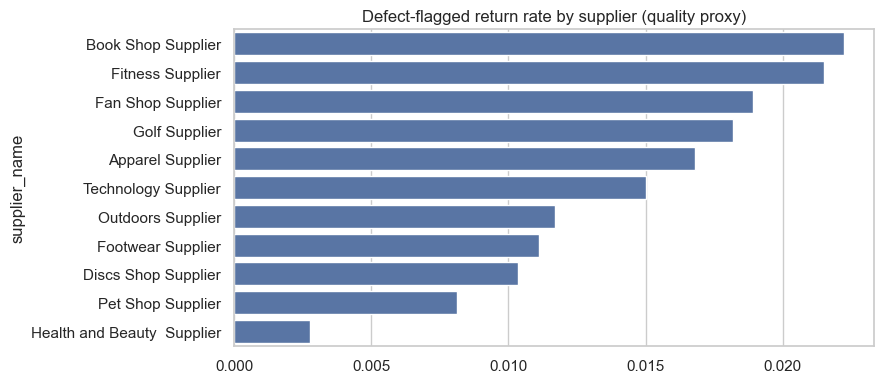

In [5]:
shipped_by_supplier = shipments.groupby('supplier_name')['quantity'].sum()
defective_by_supplier = (
    returns[returns['reason'] == 'Defective item']
    .groupby('supplier_name')['returned_quantity']
    .sum()
)
quality_proxy = (
    (defective_by_supplier / shipped_by_supplier).fillna(0).sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=quality_proxy.values, y=quality_proxy.index, ax=ax)
ax.set_title('Defect-flagged return rate by supplier (quality proxy)')
plt.tight_layout()
plt.show()

## 4. Cost

In [6]:
data_access.run_sql_file('04_supplier/13_supplier_cost_variability.sql')

,supplier_name,avg_unit_cost,unit_cost_stddev,cost_variability
0,Outdoors Supplier,122.70,201.55,1.64
1,Fitness Supplier,167.90,217.81,1.30
2,Discs Shop Supplier,277.34,239.97,0.87
3,Fan Shop Supplier,391.00,325.11,0.83
4,Technology Supplier,"1,739.57","1,357.96",0.78
5,Footwear Supplier,253.68,142.05,0.56
6,Apparel Supplier,240.30,127.68,0.53
7,Golf Supplier,140.07,21.99,0.16
8,Book Shop Supplier,89.93,0.00,0.00
9,Pet Shop Supplier,214.70,0.00,0.00


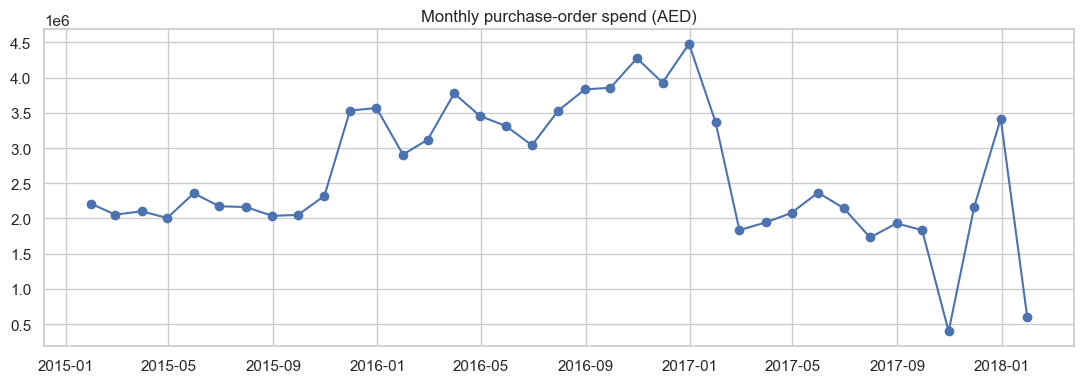

In [7]:
purchase_orders = data_access.load_purchase_orders_detail()
monthly_po_cost = purchase_orders.set_index('order_date').resample('ME')['total_cost'].sum()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly_po_cost.index, monthly_po_cost.values, marker='o')
ax.set_title('Monthly purchase-order spend (AED)')
plt.tight_layout()
plt.show()

## 5. Hypothesis test — lead-time variability across supplier groups

Tests whether the 11 suppliers' lead times come from the same distribution, or whether at least one differs — the method (ANOVA vs. Kruskal-Wallis) is chosen by testing normality/equal-variance first, not picked in advance.

In [8]:
lead_time_groups = {
    name: g['actual_lead_time_days'].dropna().to_numpy()
    for name, g in shipments.groupby('supplier_name')
}

result = stats_tests.compare_multiple_groups(
    lead_time_groups,
    question='Does lead time vary across supplier groups?',
    h0='All suppliers have the same mean/median actual lead time.',
    h1='At least one supplier\'s lead time differs from the others.',
)
print(result.summary())

Q: Does lead time vary across supplier groups?
H0: All suppliers have the same mean/median actual lead time.
H1: At least one supplier's lead time differs from the others.
Test: Kruskal-Wallis H | statistic=14.8055 | p=0.1393 | epsilon-squared=0.0000
Result: fail to reject H0 at alpha=0.05 — no statistically significant difference across 11 groups (epsilon-squared=0.000); highest mean/median: Discs Shop Supplier, lowest: Pet Shop Supplier.
